# Implementación y Evaluación del Algoritmo SARSA en Google Colab

Este notebook presenta una implementación detallada del algoritmo SARSA (State-Action-Reward-State-Action) para el aprendizaje por refuerzo. SARSA es un algoritmo de control *on-policy* que aprende la función de valor de acción (Q-función) directamente de la experiencia del agente.


## 1. Instalación y Configuración

Primero, instalaremos la librería `gymnasium` de Farama Foundation, que proporciona entornos de aprendizaje por refuerzo. Luego, importaremos todas las librerías necesarias para nuestro script.

In [ ]:
# Instalación de gymnasium
!pip install gymnasium

# Importación de librerías necesarias
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output

print("Librerías instaladas e importadas correctamente.")

Librerías instaladas e importadas correctamente.


## 2. Explicación Teórica Breve

SARSA es un algoritmo de control *on-policy*, lo que significa que aprende el valor de las acciones *para* la política que está siguiendo el agente. A diferencia de Q-Learning, que es *off-policy* y aprende la política óptima independientemente de la política de comportamiento, SARSA utiliza la acción real (A') que se toma en el siguiente estado (S') para actualizar su estimación de la función Q.

### Fórmula de Actualización de SARSA:

```
Q(S,A) = Q(S,A) + α * [R + γ * Q(S',A') - Q(S,A)]
```

Donde:
- `Q(S,A)`: El valor estimado de tomar la acción `A` en el estado `S`.
- `α` (alpha): Tasa de aprendizaje (0 < α <= 1). Determina cuánto de la nueva información se incorpora a la estimación de Q.
- `R`: La recompensa inmediata recibida después de tomar la acción `A` y transicionar a `S'`.
- `γ` (gamma): Factor de descuento (0 <= γ <= 1). Determina la importancia de las recompensas futuras. Un valor de 0 hace que el agente sea "miope", y un valor de 1 hace que considere las recompensas futuras de manera igual a las inmediatas.
- `S'` y `A'`: El siguiente estado y la siguiente acción (elegida por la misma política que generó A) respectivamente.

### ¿Por qué es On-Policy?

SARSA es *on-policy* porque su regla de actualización depende de la siguiente acción `A'` seleccionada por la *misma* política de comportamiento que el agente está ejecutando actualmente. Es decir, para actualizar `Q(S,A)`, el algoritmo necesita saber qué `A'` *realmente* va a tomar el agente en `S'`. Esto lo hace más sensible a la exploración que Q-Learning, ya que si la política de comportamiento explora, las estimaciones de Q también reflejarán esa exploración.

## 3. Simulación Práctica: Entorno FrozenLake-v1

Utilizaremos el entorno `FrozenLake-v1` de `gymnasium`. Este es un entorno discreto donde un agente debe moverse desde un punto de inicio (S) hasta un objetivo (G) a través de un lago congelado. Algunas casillas son seguras (F), mientras que otras son agujeros (H) en los que el agente caerá, terminando el episodio con una recompensa negativa. Usaremos el modo `is_slippery=True` para añadir un elemento de aleatoriedad, haciendo que el agente no siempre se mueva en la dirección deseada. Para este entorno, un algoritmo SARSA tabular es ideal.


In [ ]:
# Inicialización del entorno FrozenLake-v1
# 'is_slippery=True' significa que el agente no siempre se moverá en la dirección deseada,
# lo que añade complejidad y realismo.
entorno = gym.make('FrozenLake-v1', is_slippery=True)

# Obtener el tamaño del espacio de estados y acciones
num_estados = entorno.observation_space.n
num_acciones = entorno.action_space.n

print(f"Número de estados: {num_estados}")
print(f"Número de acciones: {num_acciones}")

# Inicialización de la tabla Q con ceros
# La tabla Q almacenará los valores Q(estado, acción)
tabla_q = np.zeros((num_estados, num_acciones))

print("Tabla Q inicializada con ceros.")

Número de estados: 16
Número de acciones: 4
Tabla Q inicializada con ceros.


In [ ]:
# Definición de hiperparámetros modificables
alpha = 0.1         # Tasa de aprendizaje (learning rate)
gamma = 0.99        # Factor de descuento (discount factor)
epsilon = 1.0       # Tasa de exploración inicial (epsilon-greedy)
epsilon_min = 0.01  # Tasa de exploración mínima
epsilon_decay = 0.001 # Tasa de decaimiento de epsilon
num_episodios = 5000 # Número total de episodios de entrenamiento
max_pasos_por_episodio = 100 # Límite de pasos por episodio para evitar bucles infinitos

# Lista para almacenar las recompensas acumuladas por episodio
recompensas_por_episodio = []

print("Hiperparámetros definidos:")
print(f"  Alpha: {alpha}")
print(f"  Gamma: {gamma}")
print(f"  Épsilon inicial: {epsilon}")
print(f"  Épsilon mínimo: {epsilon_min}")
print(f"  Decaimiento de Épsilon: {epsilon_decay}")
print(f"  Número de episodios: {num_episodios}")

Hiperparámetros definidos:
  Alpha: 0.1
  Gamma: 0.99
  Épsilon inicial: 1.0
  Épsilon mínimo: 0.01
  Decaimiento de Épsilon: 0.001
  Número de episodios: 5000


In [ ]:
# Implementación de la política Epsilon-Greedy
def elegir_accion_epsilon_greedy(estado, tabla_q, epsilon, num_acciones):
    # Con probabilidad epsilon, el agente explora (elige una acción aleatoria)
    if random.uniform(0, 1) < epsilon:
        return entorno.action_space.sample() # Acción aleatoria
    # Con probabilidad (1 - epsilon), el agente explota (elige la mejor acción según Q-table)
    else:
        return np.argmax(tabla_q[estado, :]) # Mejor acción

print("Función para la política Épsilon-Greedy definida.")

Función para la política Épsilon-Greedy definida.


In [ ]:
# Bucle de entrenamiento principal (Algoritmo SARSA)
print("Iniciando entrenamiento SARSA...")

for episodio in range(num_episodios):
    # Reiniciar el entorno al inicio de cada episodio
    estado_actual, info = entorno.reset()
    terminado = False
    truncado = False
    recompensa_acumulada = 0
    pasos_en_episodio = 0

    # Elegir la primera acción A para el estado S_actual usando la política epsilon-greedy
    accion_actual = elegir_accion_epsilon_greedy(estado_actual, tabla_q, epsilon, num_acciones)

    while not terminado and not truncado and pasos_en_episodio < max_pasos_por_episodio:
        # S -> A
        # Realizar la acción A_actual en el entorno
        siguiente_estado, recompensa, terminado, truncado, info = entorno.step(accion_actual)

        # R
        recompensa_acumulada += recompensa

        # S' -> A'
        # Elegir la siguiente acción A_siguiente para S_siguiente usando la política epsilon-greedy
        # Esta A_siguiente es crucial para SARSA (de ahí el nombre State-Action-Reward-State-Action)
        accion_siguiente = elegir_accion_epsilon_greedy(siguiente_estado, tabla_q, epsilon, num_acciones)

        # Fórmula de actualización de SARSA
        # Q(S,A) = Q(S,A) + α * [R + γ * Q(S',A') - Q(S,A)]
        antiguo_q = tabla_q[estado_actual, accion_actual]
        siguiente_q = tabla_q[siguiente_estado, accion_siguiente]

        nuevo_q_valor = antiguo_q + alpha * (recompensa + gamma * siguiente_q - antiguo_q)
        tabla_q[estado_actual, accion_actual] = nuevo_q_valor

        # Actualizar estado y acción para el siguiente paso
        estado_actual = siguiente_estado
        accion_actual = accion_siguiente
        pasos_en_episodio += 1

    # Decaimiento de Épsilon (para reducir la exploración con el tiempo)
    epsilon = max(epsilon_min, epsilon - epsilon_decay)

    recompensas_por_episodio.append(recompensa_acumulada)

    # Mostrar progreso cada cierto número de episodios
    if (episodio + 1) % 500 == 0:
        clear_output(wait=True)
        print(f"Episodio: {episodio + 1}/{num_episodios}, Épsilon: {epsilon:.2f}, Recompensa promedio (últimos 100): {np.mean(recompensas_por_episodio[-100:]):.2f}")

print("Entrenamiento SARSA completado.")

# Cerrar el entorno
entorno.close()
print("Entorno cerrado.")

Episodio: 5000/5000, Épsilon: 0.01, Recompensa promedio (últimos 100): 0.66
Entrenamiento SARSA completado.
Entorno cerrado.


## 4. Análisis de Convergencia

Para evaluar si el agente ha aprendido de manera efectiva, es fundamental analizar la evolución de las recompensas a lo largo de los episodios. Una curva de recompensa ascendente y que se estabiliza es un buen indicativo de aprendizaje.

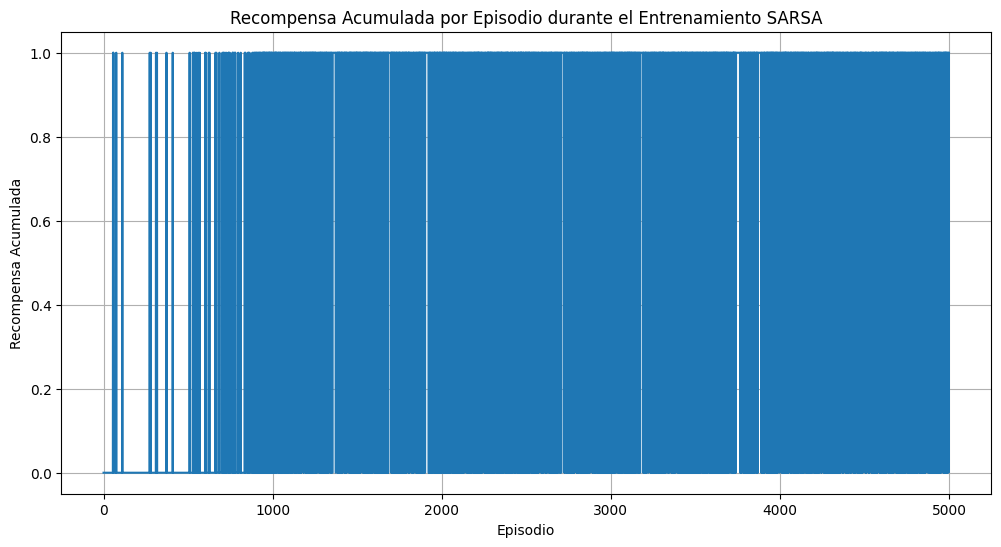

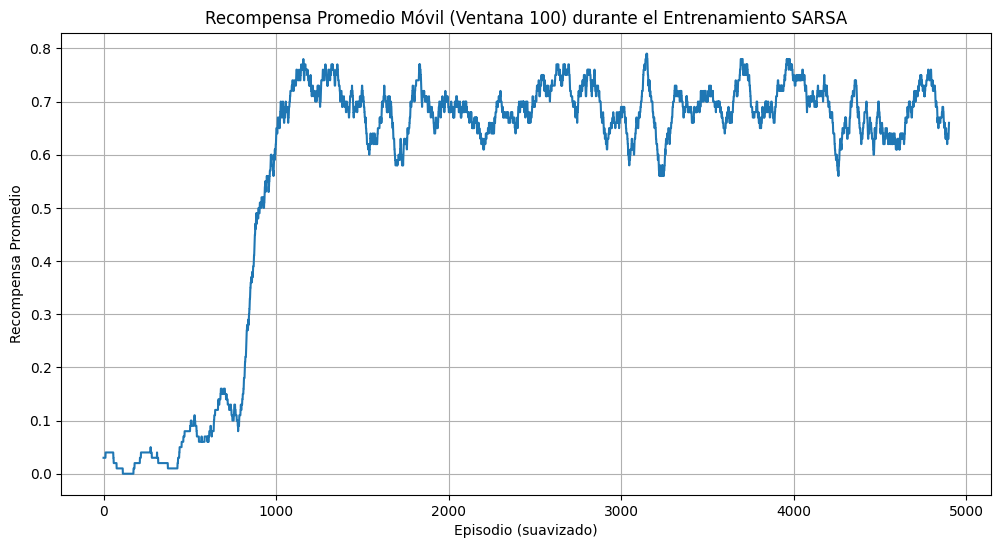

In [ ]:
# Gráfica del "Reward acumulado a lo largo de los episodios"
plt.figure(figsize=(12, 6))
plt.plot(recompensas_por_episodio)
plt.title('Recompensa Acumulada por Episodio durante el Entrenamiento SARSA')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Acumulada')
plt.grid(True)
plt.show()

# Gráfica de la recompensa promedio móvil para suavizar la curva
ventana = 100 # Ventana para el promedio móvil
recompensa_suavizada = np.convolve(recompensas_por_episodio, np.ones(ventana)/ventana, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(recompensa_suavizada)
plt.title(f'Recompensa Promedio Móvil (Ventana {ventana}) durante el Entrenamiento SARSA')
plt.xlabel('Episodio (suavizado)')
plt.ylabel('Recompensa Promedio')
plt.grid(True)
plt.show()

### Análisis de la Convergencia:

a) **Interpretación del Aprendizaje (Curva ascendente y estabilización):**
   - Si la curva de recompensa acumulada (o la suavizada) muestra una **tendencia ascendente** a medida que aumenta el número de episodios, esto indica que el agente está aprendiendo a obtener mejores recompensas con el tiempo. Está descubriendo políticas que lo llevan a estados más deseables (como el objetivo en FrozenLake) o que evitan estados indeseables (como los agujeros).
   - Una vez que la curva **se estabiliza** en un valor alto (idealmente cerca de la recompensa máxima posible por episodio), sugiere que el agente ha convergido a una política óptima (o casi óptima) dentro de las limitaciones de sus hiperparámetros y el entorno. Esto significa que la tabla Q ha dejado de cambiar significativamente y el agente consistentemente toma las mejores acciones conocidas.

b) **Inestabilidad o Estancamiento y relación con Hiperparámetros:**
   - **Inestabilidad (curva muy fluctuante):** Una curva muy errática, que sube y baja drásticamente incluso después de muchos episodios, puede indicar:
     - **Tasa de aprendizaje (α) demasiado alta:** El agente está sobreescribiendo rápidamente sus conocimientos previos con cada nueva experiencia, sin consolidar lo aprendido. Prueba a reducir `α`.
     - **Factor de descuento (γ) inadecuado:** Si `γ` es muy bajo, el agente es demasiado "miope" y no valora las recompensas futuras, lo que puede llevar a decisiones subóptimas. Si es muy alto (cercano a 1), puede ser sensible a recompensas muy lejanas, haciendo el aprendizaje más lento y volátil en entornos con muchos pasos.
     - **Exploración (ε) muy persistente:** Si `ε` no decae lo suficiente o decae muy lentamente, el agente sigue explorando demasiado, lo que impide que consolide una política buena. Asegúrate de que `epsilon_decay` sea apropiado y que `epsilon_min` no sea demasiado alto.
   - **Estancamiento (curva plana en un valor bajo):** Si la curva de recompensa se mantiene plana desde el principio o se estabiliza en un valor bajo, puede significar que el agente no está aprendiendo eficazmente. Las posibles causas son:
     - **Tasa de aprendizaje (α) demasiado baja:** El agente aprende muy lentamente y los cambios en la tabla Q son insignificantes, impidiendo la mejora.
     - **Exploración (ε) insuficiente:** El agente podría haber caído en un óptimo local y no tiene suficiente capacidad para explorar otras partes del entorno que podrían llevar a una política mejor. Aumentar `epsilon` inicial o reducir `epsilon_decay` podría ayudar.
     - **Número de episodios insuficiente:** El agente simplemente no ha tenido suficiente experiencia para aprender una buena política. Aumenta `num_episodios`.

## Despliegue con Streamlit

Para facilitar el despliegue de este proyecto en plataformas como Streamlit Sharing o ejecutarlo localmente como una aplicación web interactiva, necesitamos un archivo `requirements.txt` con todas las dependencias y un archivo `app.py` que contenga la lógica de la aplicación Streamlit.

### 1. `requirements.txt`

Este archivo lista todas las librerías de Python que tu proyecto necesita. Puedes copiar el contenido de la siguiente celda y guardarlo como `requirements.txt` en la raíz de tu repositorio de GitHub.

In [ ]:
print("""gymnasium==1.3.0
numpy==2.0.2
matplotlib==3.8.4
streamlit==1.36.0
""")

gymnasium==1.3.0
numpy==2.0.2
matplotlib==3.8.4
streamlit==1.36.0



### 2. `app.py`

Este es el script principal de tu aplicación Streamlit. Incluye la lógica del algoritmo SARSA, la configuración de hiperparámetros a través de widgets de Streamlit y la visualización de los resultados. Copia el contenido de la siguiente celda y guárdalo como `app.py` en la raíz de tu repositorio de GitHub.

### Crear `requirements.txt`

Ejecuta la siguiente celda para crear el archivo `requirements.txt` en tu entorno de Colab.

In [ ]:
# Contenido para requirements.txt
requirements_content = """gymnasium==1.3.0
numpy==2.0.2
matplotlib==3.8.4
streamlit==1.36.0
"""

# Guardar el contenido en un archivo
with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("Archivo 'requirements.txt' creado exitosamente. Puedes descargarlo desde el explorador de archivos de Colab.")

Archivo 'requirements.txt' creado exitosamente. Puedes descargarlo desde el explorador de archivos de Colab.


### Crear `app.py`

Ejecuta la siguiente celda para crear el archivo `app.py` con el código de la aplicación Streamlit.

In [ ]:
# Contenido para app.py
app_content = """import streamlit as st
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

st.set_page_config(layout="wide", page_title="Algoritmo SARSA en FrozenLake")

st.title("Implementación del Algoritmo SARSA en FrozenLake-v1")
st.markdown("Una aplicación interactiva para explorar el algoritmo SARSA en el entorno `FrozenLake-v1` de Gymnasium.")

# --- Hiperparámetros configurables --- #
st.sidebar.header("Configuración de Hiperparámetros")

alpha = st.sidebar.slider("Tasa de Aprendizaje (alpha)", 0.01, 1.0, 0.1, 0.01)
gamma = st.sidebar.slider("Factor de Descuento (gamma)", 0.01, 0.99, 0.99, 0.01)
epsilon_inicial = st.sidebar.slider("Épsilon Inicial (exploración)", 0.0, 1.0, 1.0, 0.01)
epsilon_min = st.sidebar.slider("Épsilon Mínimo", 0.0, 0.1, 0.01, 0.001)
epsilon_decay = st.sidebar.slider("Tasa de Decaimiento de Épsilon", 0.0001, 0.01, 0.001, 0.0001)
num_episodios = st.sidebar.slider("Número de Episodios", 100, 10000, 5000, 100)
max_pasos_por_episodio = st.sidebar.slider("Máx. Pasos por Episodio", 50, 500, 100, 10)

# --- Funciones SARSA --- #

def elegir_accion_epsilon_greedy(estado, tabla_q, epsilon, num_acciones):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, num_acciones - 1) # Acción aleatoria
    else:
        return np.argmax(tabla_q[estado, :]) # Mejor acción


@st.cache_resource # Cachea el entorno para evitar reinicializaciones costosas
def obtener_entorno():
    return gym.make('FrozenLake-v1', is_slippery=True)


def entrenar_sarsa(
    alpha,
    gamma,
    epsilon_inicial,
    epsilon_min,
    epsilon_decay,
    num_episodios,
    max_pasos_por_episodio,
):
    entorno = obtener_entorno()
    num_estados = entorno.observation_space.n
    num_acciones = entorno.action_space.n
    tabla_q = np.zeros((num_estados, num_acciones))
    recompensas_por_episodio = []
    epsilon = epsilon_inicial

    progreso_bar = st.progress(0, text="Entrenando SARSA...")

    for episodio in range(num_episodios):
        estado_actual, info = entorno.reset()
        terminado = False
        truncado = False
        recompensa_acumulada = 0
        pasos_en_episodio = 0

        accion_actual = elegir_accion_epsilon_greedy(estado_actual, tabla_q, epsilon, num_acciones)

        while not terminado and not truncado and pasos_en_episodio < max_pasos_por_episodio:
            siguiente_estado, recompensa, terminado, truncado, info = entorno.step(accion_actual)
            recompensa_acumulada += recompensa

            accion_siguiente = elegir_accion_epsilon_greedy(siguiente_estado, tabla_q, epsilon, num_acciones)

            antiguo_q = tabla_q[estado_actual, accion_actual]
            siguiente_q_valor = tabla_q[siguiente_estado, accion_siguiente]

            nuevo_q_valor = antiguo_q + alpha * (recompensa + gamma * siguiente_q_valor - antiguo_q)
            tabla_q[estado_actual, accion_actual] = nuevo_q_valor

            estado_actual = siguiente_estado
            accion_actual = accion_siguiente
            pasos_en_episodio += 1

        epsilon = max(epsilon_min, epsilon - epsilon_decay)
        recompensas_por_episodio.append(recompensa_acumulada)
        progreso_bar.progress((episodio + 1) / num_episodios, text=f"Episodio {episodio + 1}/{num_episodios}")

    entorno.close()
    progreso_bar.empty()
    return tabla_q, recompensas_por_episodio

# --- Botón para iniciar el entrenamiento --- #
if st.sidebar.button("Iniciar Entrenamiento SARSA"):
    st.subheader("Resultados del Entrenamiento")
    tabla_q_final, recompensas = entrenar_sarsa(
        alpha,
        gamma,
        epsilon_inicial,
        epsilon_min,
        epsilon_decay,
        num_episodios,
        max_pasos_por_episodio,
    )

    st.success("¡Entrenamiento SARSA completado!")

    st.markdown("### Tabla Q Final (primeras filas)")
    st.dataframe(tabla_q_final[:5, :]) # Mostrar solo las primeras 5 filas para evitar saturación

    st.markdown("### Gráfica de Recompensa Acumulada por Episodio")
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(recompensas)
    ax1.set_title('Recompensa Acumulada por Episodio durante el Entrenamiento SARSA')
    ax1.set_xlabel('Episodio')
    ax1.set_ylabel('Recompensa Acumulada')
    ax1.grid(True)
    st.pyplot(fig1)

    st.markdown("### Gráfica de Recompensa Promedio Móvil")
    ventana = 100
    recompensa_suavizada = np.convolve(recompensas, np.ones(ventana)/ventana, mode='valid')
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    ax2.plot(recompensa_suavizada)
    ax2.set_title(f'Recompensa Promedio Móvil (Ventana {ventana}) durante el Entrenamiento SARSA')
    ax2.set_xlabel('Episodio (suavizado)')
    ax2.set_ylabel('Recompensa Promedio')
    ax2.grid(True)
    st.pyplot(fig2)

    st.markdown("### Análisis de la Convergencia")
    st.markdown("**Interpretación del Aprendizaje (Curva ascendente y estabilización):**")
    st.markdown("Si la curva de recompensa promedio móvil muestra una **tendencia ascendente** y luego **se estabiliza** en un valor alto, indica que el agente está aprendiendo y convergiendo a una política efectiva. Esto significa que está encontrando rutas para alcanzar el objetivo (G) y evitar los agujeros (H).")
    st.markdown("**Inestabilidad o Estancamiento y relación con Hiperparámetros:**")
    st.markdown("Si las curvas son muy fluctuantes (inestabilidad) o se mantienen bajas (estancamiento), es posible que los hiperparámetros (alpha, gamma, epsilon) necesiten ajustarse. Una `alpha` muy alta puede causar inestabilidad, mientras que una `epsilon` insuficiente puede llevar a un estancamiento en un óptimo local.")

else:
    st.info("Ajusta los hiperparámetros en la barra lateral izquierda y haz clic en 'Iniciar Entrenamiento SARSA' para comenzar.")

st.markdown("--- ")
st.markdown("**Nota sobre el Entorno FrozenLake-v1:**")
st.markdown("El entorno `FrozenLake-v1` (`is_slippery=True`) simula un suelo congelado donde el agente debe navegar desde el inicio (S) hasta el objetivo (G). Las casillas 'F' son seguras, 'H' son agujeros. La propiedad `is_slippery=True` introduce aleatoriedad: la acción deseada solo ocurre con una probabilidad, y en otras ocasiones el agente se desliza a una casilla adyacente aleatoria. Esto hace que el problema sea más desafiante y requiere que el agente aprenda una política robusta.")"""

# Guardar el contenido en un archivo
with open("app.py", "w") as f:
    f.write(app_content)

print("Archivo 'app.py' creado exitosamente. Puedes descargarlo desde el explorador de archivos de Colab.")

Archivo 'app.py' creado exitosamente. Puedes descargarlo desde el explorador de archivos de Colab.


### Cómo descargar los archivos:

1.  En la barra lateral izquierda de Colab, haz clic en el icono de la carpeta (Explorador de archivos).
2.  Busca `requirements.txt` y `app.py` en la lista de archivos.
3.  Haz clic en los tres puntos verticales junto a cada nombre de archivo y selecciona "Descargar".